In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
# === READ PUERTOS DEL ESTADO TXT WAVE FILE ===
filename = "puertos_del_estado.txt"   # <-- same file as before

# Read numeric matrix skipping first 2 header lines
A = np.loadtxt(filename, skiprows=2)

In [8]:
# Replace missing values (-9999.9)
A[A == -9999.9] = np.nan

# Build datetime from columns: YYYY MM DD HH
time = pd.to_datetime(
    dict(year=A[:,0].astype(int),
         month=A[:,1].astype(int),
         day=A[:,2].astype(int),
         hour=A[:,3].astype(int))
)

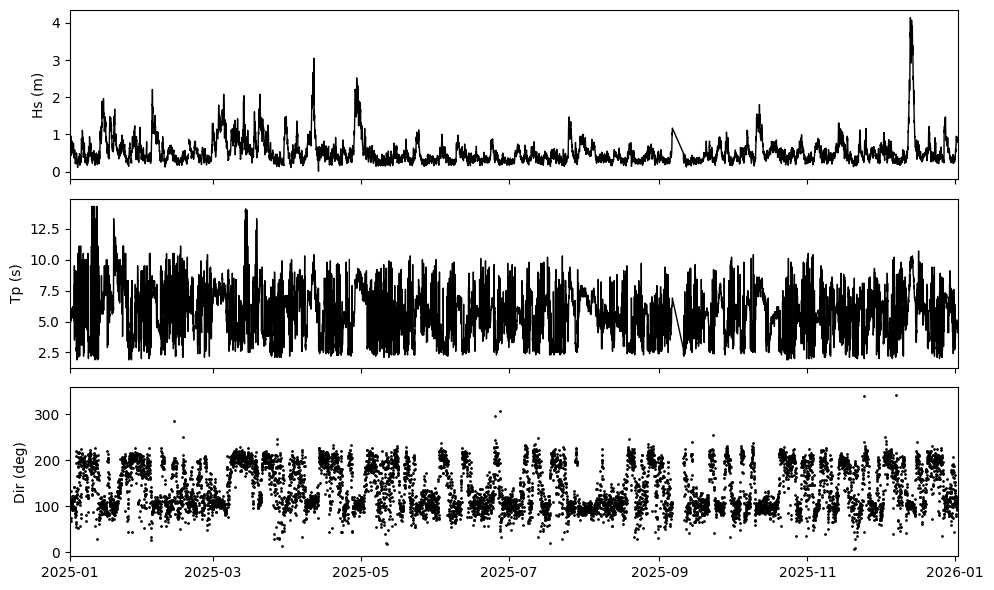

In [9]:
# Extract main wave parameters (MATLAB cols 5,9,13 -> Python 0-index 4,8,12)
Hs  = A[:,4]    # Significant wave height (m)
Tp  = A[:,8]    # Peak period (s)
Dir = A[:,12]   # Mean wave direction (FROM, deg), 0=N,90=E

# -------------------- QUICK CHECK PLOTS --------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axes[0].plot(time, Hs, 'k', lw=1)
axes[0].set_ylabel("Hs (m)")
axes[1].plot(time, Tp, 'k', lw=1)
axes[1].set_ylabel("Tp (s)")
axes[2].plot(time, Dir, 'k.', ms=2)
axes[2].set_ylabel("Dir (deg)")
axes[2].set_xlim(time.iloc[0], time.iloc[-1])
for ax in axes:
    ax.tick_params(labelsize=10)
plt.tight_layout()

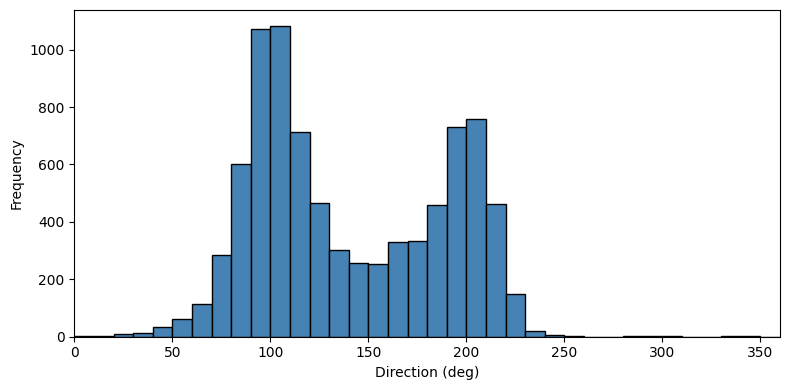

In [10]:
plt.figure(figsize=(8,4))
bins_dir = np.arange(0, 361, 10)
plt.hist(Dir[np.isfinite(Dir)], bins=bins_dir, color='steelblue', edgecolor='k')
plt.xlabel("Direction (deg)")
plt.ylabel("Frequency")
plt.xlim(0, 360)
plt.tight_layout()

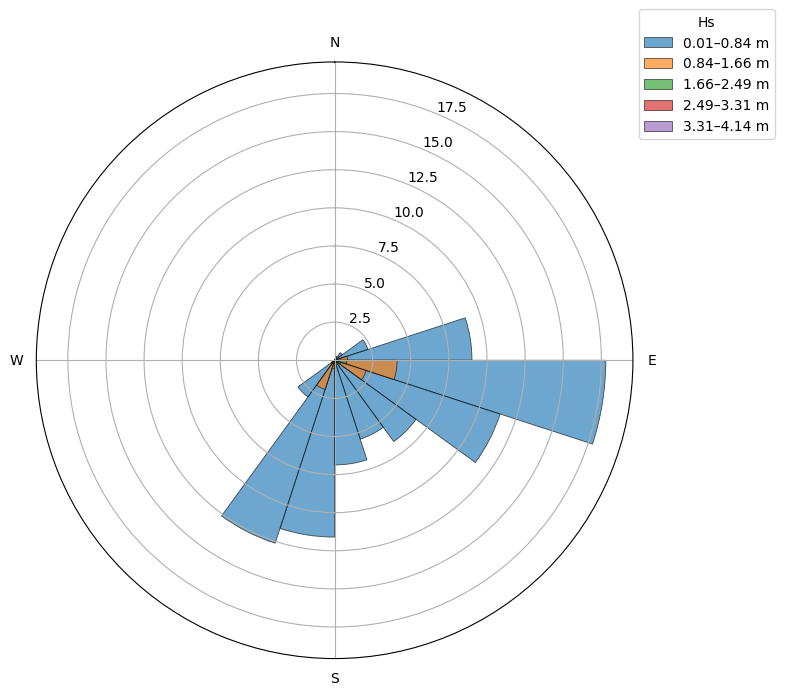

In [11]:
# -------------------- WAVE ROSE (Hs-binned) --------------------
ok = np.isfinite(Hs) & np.isfinite(Dir)
heights = Hs[ok]
dirs    = np.mod(Dir[ok], 360.0)  # keep FROM direction

xn = 5
yn = 20

# Direction edges (same as your MATLAB: linspace)
Yedges = np.linspace(0, 360, yn+1)

# Height edges (same as your MATLAB: linear min..max)
Xedges = np.linspace(np.nanmin(heights), np.nanmax(heights), xn+1)

# 2D histogram (rows=Hs bins, cols=Dir bins)
N, xedges, yedges = np.histogram2d(heights, dirs, bins=[Xedges, Yedges])

probs = N / np.nansum(N) * 100.0  # % occurrence

# Polar setup: 0=N, 90=E, clockwise (compass)
fig = plt.figure(figsize=(8,7))
ax = plt.subplot(111, projection='polar')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

theta_edges = np.deg2rad(Yedges)
theta_centers = (theta_edges[:-1] + theta_edges[1:]) / 2
width = np.diff(theta_edges)

handles = []
for i in range(probs.shape[0]):  # each Hs bin
    bars = ax.bar(theta_centers, probs[i, :], width=width, align='center',
                  alpha=0.65, edgecolor='k', linewidth=0.6)
    handles.append(bars[0])

ax.set_thetagrids([0, 90, 180, 270], labels=['N','E','S','W'])
ax.set_rlabel_position(22.5)
ax.set_ylim(0, max(5, np.nanmax(probs)*1.1))

# Legend labels (Hs bins)
labels = [f"{Xedges[i]:.2f}–{Xedges[i+1]:.2f} m" for i in range(xn)]
ax.legend(handles, labels, title="Hs", loc='upper right', bbox_to_anchor=(1.25, 1.10))

plt.tight_layout()
plt.show()